# Synthetic Data Classification — OAT Sampling Strategies

This notebook presents a reproducible experimental pipeline for evaluating **Online Active Testing (OAT)** strategies on a synthetic two-moon classification task.

We compare several sampling strategies for estimating model performance under a constrained annotation budget: Uniform sampling, OAT (1st moment), OAT (2nd moment), and Oracle strategy. Through sufficient repetition, this notebook helps visualise the unbiased characteristics of the baseline, OAT strategies, and the oracle, as well as the resulting variance.

## Experimental Setting

- Dataset: `make_moons`
- Model: Random Forest
- Surrogate model: Random Forest
- Evaluation metric: Binary cross-entropy loss or 0-1 loss


In [1]:
import os
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

# Import libraries

In [2]:
# Machine learning library
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split



# For online active testing
from OAT.sampling_classification import compute_expected_loss_classification_CE, compute_expected_squared_loss_classification_CE
from OAT.sampling_classification import compute_expected_loss_classification_01, compute_expected_squared_loss_classification_01
from OAT.OAT import oat_estimate, run_adaptive_selection

# Utils
from utils.per_sample_loss_function import per_sample_binary_log_loss, per_sample_01_loss
from utils.Historic import Historic
from utils.utils import cummean


In [3]:
#Experiments configuration
config_exp = {
    "CE": {
        'per_sample_loss': per_sample_binary_log_loss,
        '1st_moment': compute_expected_loss_classification_CE,
        '2nd_moment': compute_expected_squared_loss_classification_CE
        },
    "01": {
        'per_sample_loss': per_sample_01_loss,
        '1st_moment': compute_expected_loss_classification_01,
        '2nd_moment': compute_expected_squared_loss_classification_01
        }
}


# Experimental Configuration

We define the hyperparameters of the OAT method on the 2-moon dataset. `loss_choice` is the type of loss we want to estimate, where "CE" is for cross-entropy and  "01" is for 0-1 loss. `nb_repet` is the number of repetitions for test via OAT. We generate `nb_points` and train the model using `train_size`. The model is then evaluated on a stream of `T_stream` points with a budget of `budget`. 

In [4]:
random_seed = 42
#Hyperparameters
loss_choice = "01"
nb_repet = 20

##Dataset generation
nb_points = 500
train_size = 20

##OAT hyperparamet
T_stream = 200
budget = 50

#Create folder to save results
save_dir = 'results/2moon/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Dataset generation and model training
We additionally compute the per-sample loss of the points remaining in the stream and print the risk that we want to estimate.


In [5]:
#Dataset Generation
X, y = make_moons(n_samples=nb_points, noise=0.1, random_state=random_seed)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=train_size, random_state=random_seed)

#Main model to evaluate
model_main = RandomForestClassifier(random_state=random_seed)
model_main.fit(X_train, y_train)

#Compute per sample losses in the stream
losses = config_exp[loss_choice]['per_sample_loss'](model_main, X_test, y_test)
true_loss = np.mean(losses)
print("Model's risk", true_loss)

Model's risk 0.09791666666666667


# Surrogate model
The auxiliary model here is a Random Forest initialised on the train dataset. We additionally show how we compute the first and second moment of the loss given the model to evaluate, the main model and samples.



In [6]:
#Auxialiary model pi
model_aux = RF_aux = RandomForestClassifier(random_state=random_seed)
model_aux.fit(X_train, y_train)


#Compute per 1st moment and second moment of the loss
loss_1stmoment = config_exp[loss_choice]['1st_moment'](model_main, model_aux, X_test)
loss_2ndmoment = config_exp[loss_choice]['2nd_moment'](model_main, model_aux, X_test)

# Sampling Strategies
We compare the four strategies presented in the article:
- Uniform: sampling points uniformly according to the budget $\beta_t=n_B/T$.
- Oracle: sampling points proportionally to the actual loss $L(\theta,x,y)$
- OAT 1st-moment: sampling points proportionally to the 1st moment of the loss given by the surrogate model $\mathbb{E}_\pi[L(\theta,x,y)]$.
- OAT 2nd-moment: sampling points proportionally to the square root of the 2nd moment of the loss $\sqrt{\mathbb{E}_\pi[L(\theta,x,y)^2]}$.

`Historic` class help storing experiments results.

In [7]:
STRATEGIES_CONFIG = {
    "Uniform":           {"adaptive": False, "metric": None, "fixed_beta": budget/T_stream},
    "Oracle":            {"adaptive": False, "metric": losses, "fixed_beta": None},
    "OAT 1st-moment":    {"adaptive": True,  "metric": loss_choice + "_1stmoment", "fixed_beta": None},#Adaptive IS 1st moment strategy
    "OAT 2nd-moment":    {"adaptive": True,  "metric": loss_choice + "_2ndmoment", "fixed_beta": None},#Adaptive IS 2nd moment strategy
}


# Initialise history objects in a dictionary
histories = {name: Historic(name, T_stream, budget, nb_repet) for name in STRATEGIES_CONFIG}


# OAT Streaming Procedure
At each iteration, a permutation is sampled to introduce randomness in the stream.

In [8]:
#Loop
for repet in tqdm(range(nb_repet)):
    # Shared permutation for this repetition
    permutation = np.random.permutation(len(X_test))[:T_stream]
    losses_permuted = losses[permutation]


    # We instantiate the RF once per repetition to be used by all adaptive strategies
    model_aux = RandomForestClassifier(random_state=random_seed)

    for name, config in STRATEGIES_CONFIG.items():
        if config["adaptive"]:
                # Adaptive Strategy: Calls the run_adaptive_selection fonction
                selection, p_selection = run_adaptive_selection(
                    model_main, model_aux, X_train, y_train, X_test, y_test, 
                    permutation, T_stream, budget, config["metric"]
                )
        else:
            # Non-Adaptive Strategy
            if config["fixed_beta"] is not None:
                p_selection = np.ones(T_stream) * config["fixed_beta"]
            else:
                # IS Strategy: beta = metric / cummean(metric) * budget/T
                metric_vals = config["metric"][permutation]
                p_selection = (metric_vals / (cummean(metric_vals) + 1e-15)) * (budget / T_stream)
                p_selection = np.minimum(p_selection, 1.0)
            # Generate selection mask based on the probabilities
            selection = np.random.uniform(size=T_stream) < p_selection

        histories[name].update(
            scores = oat_estimate(losses_permuted, selection, p_selection, T_stream),
            selection = selection,
            permutation = permutation,
            probabilities = p_selection,
            run_id = repet
        )

  0%|          | 0/20 [00:00<?, ?it/s]

In [9]:
#Save and transform data to DataFrame
df_dict = {}
for name, _ in STRATEGIES_CONFIG.items():
    histories[name].save_to_csv(direction=save_dir) 
    df_dict[name] = histories[name].to_dataframe()

Data saved to: results/2moon/Uniform_20_200_50.csv
Data saved to: results/2moon/Oracle_20_200_50.csv
Data saved to: results/2moon/OAT 1st-moment_20_200_50.csv
Data saved to: results/2moon/OAT 2nd-moment_20_200_50.csv


# Visualisation


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from utils_visu import *

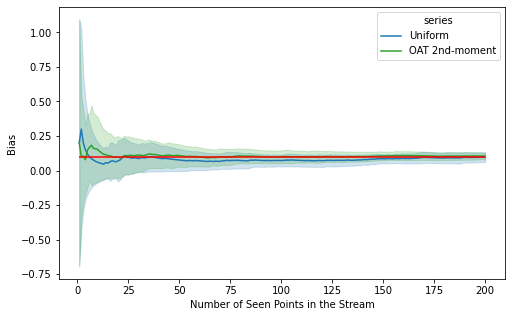

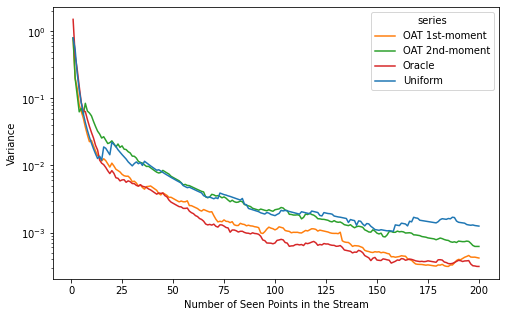

In [11]:
all_series = ['Uniform', 'OAT 1st-moment', 'OAT 2nd-moment', 'Oracle'] 
colors = sns.color_palette("tab10", len(all_series)) 
my_palette = dict(zip(all_series, colors))



#Plot biais
data_to_show = pd.concat([df_dict['Uniform'], df_dict['OAT 2nd-moment']])
plot_biais(data_to_show, true_loss, x='time', savefig=save_dir + "Bias", palette=my_palette)



#Plot Variance
data_to_show = pd.concat([df_dict['Uniform'], df_dict['OAT 1st-moment'], df_dict['OAT 2nd-moment'], df_dict['Oracle']])

plot_variance(data_to_show, true_loss, x='time', savefig=save_dir + "Variance", palette=my_palette)
